In [1]:
from datasets import load_dataset

ds = load_dataset("Djacon/ru-izard-emotions")

INFO: TensorFlow version 2.20.0 available.


In [2]:
import pandas as pd

df = ds["train"].to_pandas()

In [3]:
df.head(100)

,text,neutral,joy,sadness,anger,enthusiasm,surprise,disgust,fear,guilt,shame
0,Ты дебил,0,0,0,1,0,0,1,0,0,0
1,Я чувствую себя так глупо. Я никогда не видел ...,0,0,0,1,0,0,1,0,0,0
2,"Это правда, их послужной список не очень хорош...",0,0,0,1,0,0,0,0,0,0
3,Это факт. Так что ваши обвинения просто основа...,0,0,0,1,1,0,0,0,0,0
4,"Моему сыну 10 месяцев. Я надеюсь, что у нас бу...",0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
95,"Кто, по-вашему, может привести ""Пэкерс"" туда, ...",0,0,0,0,1,0,0,0,0,0
96,Это действительно раздражает только в случае ч...,0,0,0,1,0,0,0,0,0,0
97,"О, смотрите, игрок выходит из спада против ""Да...",0,0,0,0,0,1,0,0,0,0
98,Пэм Бизли и Джим... Какая потеря.,0,0,1,1,0,0,1,0,0,0


Counts per label:
 neutral       6775
anger         6386
joy           5929
sadness       5260
enthusiasm    4216
surprise      2232
disgust       2224
fear          1996
shame         1115
guilt         1112
dtype: int64


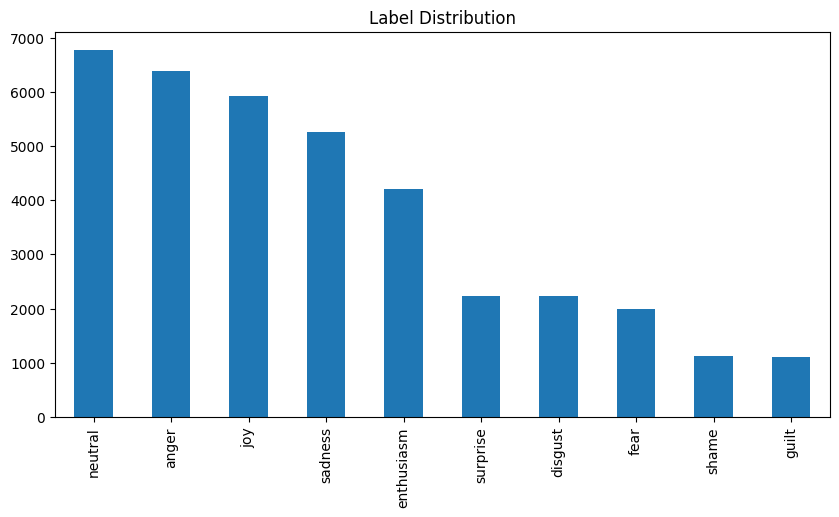

In [4]:
import matplotlib.pyplot as plt

# 1. Count per label
label_counts = df.iloc[:, 1:].sum().sort_values(ascending=False)
print("Counts per label:\n", label_counts)

# Plot distribution
label_counts.plot(kind="bar", figsize=(10, 5), title="Label Distribution")
plt.show()

In [5]:
# 2. Count label co-occurrence per sample
df["num_labels"] = df.iloc[:, 1:].sum(axis=1)
print(df["num_labels"].value_counts())

# 3. Check rows with no labels at all
no_labels = df[df["num_labels"] == 0]
print("Samples with no labels:", len(no_labels))

num_labels
1    8781
2    7129
3    3058
4     968
5     201
6      20
7       5
Name: count, dtype: int64
Samples with no labels: 0


In [6]:
df_1 = df.drop(columns=["shame", "guilt", "num_labels"])

In [7]:
label_counts = df_1.iloc[:, 1:].sum().sort_values(ascending=False)
print("Counts per label:\n", label_counts)

Counts per label:
 neutral       6775
anger         6386
joy           5929
sadness       5260
enthusiasm    4216
surprise      2232
disgust       2224
fear          1996
dtype: int64


In [12]:
import numpy as np


def downsample_multilabel_precise(df, target_count=1996, random_state=42):
    """
    Precise multilabel downsampling to achieve exact target_count per label.
    Iteratively selects samples to maintain perfect balance.
    """
    np.random.seed(random_state)

    # Get label columns (skip first text column)
    label_cols = df.columns[1:].tolist()
    print(f"Processing {len(label_cols)} labels: {label_cols}")

    # Initialize tracking
    current_counts = {label: 0 for label in label_cols}
    target_counts = {label: target_count for label in label_cols}
    available_indices = set(df.index)
    selected_indices = []

    print(f"Target count per label: {target_count}")
    print(f"Starting with {len(available_indices)} available samples")
    print("Starting downsampling process...")

    iteration = 0

    while True:
        iteration += 1

        # Check if we're done
        needed_labels = [
            label for label in label_cols if current_counts[label] < target_counts[label]
        ]

        if not needed_labels:
            print("All labels reached target count!")
            break

        if not available_indices:
            print("No more available samples!")
            break

        # Find candidate indices that have at least one needed label
        candidate_indices = []
        for idx in available_indices:
            row = df.loc[idx]
            if any(row[label] == 1 for label in needed_labels):
                candidate_indices.append(idx)

        if not candidate_indices:
            print("No more candidates with needed labels!")
            break

        # Prioritize samples that help with most under-represented labels
        best_candidates = []
        max_help_score = 0

        for idx in candidate_indices:
            row = df.loc[idx]
            help_score = 0

            # Score based on how much this sample helps under-represented labels
            for label in needed_labels:
                if row[label] == 1:
                    remaining_needed = target_counts[label] - current_counts[label]
                    help_score += remaining_needed  # Prioritize labels that need more samples

            if help_score > max_help_score:
                max_help_score = help_score
                best_candidates = [idx]
            elif help_score == max_help_score:
                best_candidates.append(idx)

        # Randomly select from best candidates
        selected_idx = np.random.choice(best_candidates)
        selected_indices.append(selected_idx)
        available_indices.remove(selected_idx)

        # Update counts
        row = df.loc[selected_idx]
        for label in label_cols:
            if row[label] == 1:
                current_counts[label] += 1

        # Verbose output every 100 iterations
        if len(selected_indices) % 100 == 0:
            print(f"Selected {len(selected_indices)} samples. Current progress:")
            for label in label_cols:
                progress = current_counts[label]
                print(
                    f"  {label}: {progress}/{target_count} ({progress / target_count * 100:.1f}%)"
                )

    # Final results
    balanced_df = df.loc[selected_indices].copy().reset_index(drop=True)

    print("\nDownsampling completed!")
    print(f"Selected {len(selected_indices)} total samples")
    print(f"Original dataset: {df.shape[0]} samples")
    print(f"Balanced dataset: {balanced_df.shape[0]} samples")

    print("\nFinal label counts:")
    final_counts = balanced_df.iloc[:, 1:].sum()
    for label in label_cols:
        count = final_counts[label]
        print(f"  {label}: {count}")

    return balanced_df


# Execute the downsampling
balanced_df = downsample_multilabel_precise(df_1, target_count=1996, random_state=42)

# Verify the results
print("\nVerification:")
verification_counts = balanced_df.iloc[:, 1:].sum().sort_values(ascending=False)
print("Final counts per label:")
for label, count in verification_counts.items():
    print(f"  {label}: {count}")

print(f"\nBalanced dataset shape: {balanced_df.shape}")
print("Ready to use: balanced_df")

Processing 8 labels: ['neutral', 'joy', 'sadness', 'anger', 'enthusiasm', 'surprise', 'disgust', 'fear']
Target count per label: 1996
Starting with 20162 available samples
Starting downsampling process...
Selected 100 samples. Current progress:
  neutral: 58/1996 (2.9%)
  joy: 59/1996 (3.0%)
  sadness: 66/1996 (3.3%)
  anger: 67/1996 (3.4%)
  enthusiasm: 60/1996 (3.0%)
  surprise: 58/1996 (2.9%)
  disgust: 60/1996 (3.0%)
  fear: 51/1996 (2.6%)
Selected 200 samples. Current progress:
  neutral: 110/1996 (5.5%)
  joy: 110/1996 (5.5%)
  sadness: 110/1996 (5.5%)
  anger: 111/1996 (5.6%)
  enthusiasm: 111/1996 (5.6%)
  surprise: 110/1996 (5.5%)
  disgust: 109/1996 (5.5%)
  fear: 108/1996 (5.4%)
Selected 300 samples. Current progress:
  neutral: 158/1996 (7.9%)
  joy: 158/1996 (7.9%)
  sadness: 173/1996 (8.7%)
  anger: 173/1996 (8.7%)
  enthusiasm: 159/1996 (8.0%)
  surprise: 157/1996 (7.9%)
  disgust: 158/1996 (7.9%)
  fear: 143/1996 (7.2%)
Selected 400 samples. Current progress:
  neutral:

In [14]:
balanced_df.to_pickle("balanced_emotions_small.pkl")